# Lab 5.1 Fine-tuning моделей BERT и GPT


## 1. BERT для transfer learning

BERT — это transformer типа **encoder-only**, предварительно обученный с помощью masked language modeling. Типичные варианты transfer learning:
- замороженный feature extractor и небольшая classification head;
- полный fine-tuning всех параметров;
- parameter-efficient fine-tuning (adapters/LoRA) для снижения вычислительных затрат (мы обсудим его через две недели).

![Схема transfer learning для BERT](attachment:bert-transfer.svg)

*Источник исходной идеи: https://towardsdatascience.com/a-complete-guide-to-bert-with-code-9f87602e4a11/*


In [1]:
# Краткий пример BERT: контекстное предсказание с [MASK]
from transformers import pipeline

fill_mask = pipeline('fill-mask', model='bert-base-uncased')
examples = [
    'The course project was [MASK] and practical.',
    'Transfer learning made this task much [MASK].'
]

for sent in examples:
    print(sent)
    print(fill_mask(sent, top_k=3))
    print('-' * 80)

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.weight    | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


The course project was [MASK] and practical.
[{'score': 0.15836673974990845, 'token': 3722, 'token_str': 'simple', 'sequence': 'the course project was simple and practical.'}, {'score': 0.055501263588666916, 'token': 6742, 'token_str': 'practical', 'sequence': 'the course project was practical and practical.'}, {'score': 0.045261070132255554, 'token': 3733, 'token_str': 'easy', 'sequence': 'the course project was easy and practical.'}]
--------------------------------------------------------------------------------
Transfer learning made this task much [MASK].
[{'score': 0.8055573105812073, 'token': 6082, 'token_str': 'easier', 'sequence': 'transfer learning made this task much easier.'}, {'score': 0.14077286422252655, 'token': 6211, 'token_str': 'harder', 'sequence': 'transfer learning made this task much harder.'}, {'score': 0.039529796689748764, 'token': 16325, 'token_str': 'simpler', 'sequence': 'transfer learning made this task much simpler.'}]
------------------------------------

### 1.1 Transfer learning с BERT для NER: до и после fine-tuning

Используем датасет **CoNLL-2003** для NER и сравним качество:
- **до fine-tuning**: предварительно обученный BERT и случайно инициализированная token-classification head;
- **после fine-tuning**: тот же checkpoint BERT, адаптированный к меткам NER.

Чтобы обучение на занятии занимало разумное время, используем небольшую подвыборку.


In [2]:
!pip install evaluate seqeval

In [3]:
# Настройка BERT для NER и загрузка данных
import torch
from datasets import load_dataset, DatasetDict
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import evaluate
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    DataCollatorForTokenClassification,
    get_scheduler,
)

device = torch.device('cuda') if torch.cuda.is_available() else 'cpu'
print('Device:', device)

dataset = load_dataset("lhoestq/conll2003")

# Небольшая подвыборка ускоряет занятие; для лучшего качества увеличьте её размер
small_ds = DatasetDict({
    'train': dataset['train'].shuffle(seed=42).select(range(2000)),
    'validation': dataset['validation'].shuffle(seed=42).select(range(500)),
    'test': dataset['test'].shuffle(seed=42).select(range(500)),
})

# В оригинальном conll2003 ner_tags был Sequence(ClassLabel), поэтому имена
# можно было получить через .feature.names. В lhoestq/conll2003 это
# Sequence(Value), и metadata с именами классов отсутствует.
ner_tag_feature = dataset['train'].features['ner_tags'].feature

if hasattr(ner_tag_feature, 'names') and ner_tag_feature.names is not None:
    label_list = ner_tag_feature.names
else:
    # Стандартное соответствие ID меткам из CoNLL-2003.
    label_list = [
        'O',
        'B-PER', 'I-PER',
        'B-ORG', 'I-ORG',
        'B-LOC', 'I-LOC',
        'B-MISC', 'I-MISC',
    ]

    # Защита от незаметного изменения схемы датасета в будущем.
    observed_label_ids = {
        tag_id
        for tags in dataset['train']['ner_tags']
        for tag_id in tags
    }
    unknown_label_ids = observed_label_ids - set(range(len(label_list)))
    if unknown_label_ids:
        raise ValueError(f'Неизвестные NER label IDs: {sorted(unknown_label_ids)}')
id2label = {i: label for i, label in enumerate(label_list)}
label2id = {label: i for i, label in id2label.items()}

model_ckpt = 'bert-base-cased'
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

print('Label set:', label_list)
print('Train/Val/Test sizes:', len(small_ds['train']), len(small_ds['validation']), len(small_ds['test']))

Device: cuda
Label set: ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']
Train/Val/Test sizes: 2000 500 500


In [4]:
# Токенизация и сопоставление NER tags уровня слов с subword tokens
def tokenize_and_align_labels(examples):
    tokenized = tokenizer(
        examples['tokens'],
        truncation=True,
        is_split_into_words=True
    )

    all_labels = []
    for i, word_labels in enumerate(examples['ner_tags']):
        word_ids = tokenized.word_ids(batch_index=i)
        prev_word_id = None
        label_ids = []

        for word_id in word_ids:
            if word_id is None:
                label_ids.append(-100)
            elif word_id != prev_word_id:
                label_ids.append(word_labels[word_id])
            else:
                label_ids.append(-100)
            prev_word_id = word_id

        all_labels.append(label_ids)

    tokenized['labels'] = all_labels
    return tokenized

tokenized_ds = small_ds.map(
    tokenize_and_align_labels,
    batched=True,
    remove_columns=small_ds['train'].column_names
)

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)
seqeval = evaluate.load('seqeval')

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

In [5]:
# DataLoader и вспомогательные функции
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)
seqeval = evaluate.load('seqeval')

train_batch_size = 16
eval_batch_size = 16
num_train_epochs = 1
learning_rate = 2e-5
weight_decay = 0.01

train_loader = DataLoader(
    tokenized_ds['train'],
    batch_size=train_batch_size,
    shuffle=True,
    collate_fn=data_collator
)
test_loader = DataLoader(
    tokenized_ds['test'],
    batch_size=eval_batch_size,
    shuffle=False,
    collate_fn=data_collator
)

def compute_seqeval_metrics(all_preds, all_labels):
    results = seqeval.compute(predictions=all_preds, references=all_labels)
    return {
        'precision': results['overall_precision'],
        'recall': results['overall_recall'],
        'f1': results['overall_f1'],
        'accuracy': results['overall_accuracy'],
    }

def evaluate_model(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}
            logits = model(**batch).logits
            pred_ids = logits.argmax(dim=-1).cpu().numpy()
            label_ids = batch['labels'].cpu().numpy()

            for pred_seq, label_seq in zip(pred_ids, label_ids):
                cur_preds = []
                cur_labels = []
                for p, l in zip(pred_seq, label_seq):
                    if l != -100:
                        cur_preds.append(label_list[int(p)])
                        cur_labels.append(label_list[int(l)])
                all_preds.append(cur_preds)
                all_labels.append(cur_labels)

    return compute_seqeval_metrics(all_preds, all_labels)

Оценим модель BERT без обучения.


In [6]:

model_before = AutoModelForTokenClassification.from_pretrained(
    model_ckpt,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id
).to(device)

before_metrics = evaluate_model(model_before, test_loader)
print('Before fine-tuning:', {k: round(v, 4) for k, v in before_metrics.items()})

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly i

Before fine-tuning: {'precision': np.float64(0.0243), 'recall': np.float64(0.1325), 'f1': np.float64(0.0411), 'accuracy': 0.2318}


Теперь обучим модель в течение одной эпохи.


In [7]:
# Fine-tuning в цикле на чистом PyTorch (без Trainer и зависимости accelerate)
# Инициализируем новую модель BERT для token classification с метками NER.
# Эту модель адаптируем на training split.
model_after = AutoModelForTokenClassification.from_pretrained(
    model_ckpt,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id
).to(device)

optimizer = torch.optim.AdamW(model_after.parameters(), lr=learning_rate, weight_decay=weight_decay)

num_training_steps = num_train_epochs * len(train_loader)
lr_scheduler = get_scheduler(
    name='linear',
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps,
)

# Цикл обучения: forward -> loss -> backward -> шаг optimizer -> шаг scheduler.
model_after.train()
for epoch in range(num_train_epochs):
    progress = tqdm(train_loader, desc=f'Epoch {epoch + 1}/{num_train_epochs}')
    for batch in progress:
        # Переносим все tensors из batch на CPU/GPU.
        batch = {k: v.to(device) for k, v in batch.items()}

        # Вычисляем loss для классификации на уровне tokens.
        outputs = model_after(**batch)
        loss = outputs.loss

        # Выполняем backpropagation и обновляем параметры.
        loss.backward()
        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()

        # Показываем текущий loss в progress bar.
        progress.set_postfix({'loss': float(loss.detach().cpu())})

# Оцениваем модель после fine-tuning на test split.
after_metrics = evaluate_model(model_after, test_loader)

# Сравниваем качество до и после transfer learning; основная метрика — F1.
print(f"F1 before fine-tuning: {before_metrics['f1']:.4f}")
print(f"F1 after fine-tuning:  {after_metrics['f1']:.4f}")
print(f"Absolute gain:          {after_metrics['f1'] - before_metrics['f1']:+.4f}")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly i

Epoch 1/1:   0%|          | 0/125 [00:00<?, ?it/s]

F1 before fine-tuning: 0.0411
F1 after fine-tuning:  0.4885
Absolute gain:          +0.4474


In [8]:
# Качественная проверка на одном предложении: эталон, до и после fine-tuning
sample_idx = 0
sample_tokens = small_ds['test'][sample_idx]['tokens']
gold_ids = small_ds['test'][sample_idx]['ner_tags']
gold_labels = [label_list[i] for i in gold_ids]

def predict_word_level_labels(model, words):
    model.eval()
    encoded = tokenizer(words, is_split_into_words=True, return_tensors='pt', truncation=True)
    encoded = {k: v.to(device) for k, v in encoded.items()}
    with torch.no_grad():
        logits = model(**encoded).logits[0]
    pred_ids = logits.argmax(dim=-1).detach().cpu().tolist()
    word_ids = tokenizer(words, is_split_into_words=True, truncation=True).word_ids()

    preds = []
    prev_word = None
    for tok_pos, word_id in enumerate(word_ids):
        if word_id is None or word_id == prev_word:
            prev_word = word_id
            continue
        preds.append(label_list[pred_ids[tok_pos]])
        prev_word = word_id
    return preds

pred_before = predict_word_level_labels(model_before, sample_tokens)
pred_after = predict_word_level_labels(model_after, sample_tokens)

print('token		gold	before	after')
for tok, g, b, a in zip(sample_tokens, gold_labels, pred_before, pred_after):
    print(f'{tok:12s}	{g:7s}	{b:7s}	{a:7s}')

token		gold	before	after
Hartford    	B-ORG  	O      	B-ORG  
4           	O      	I-PER  	O      
BOSTON      	B-ORG  	B-ORG  	B-LOC  
2           	O      	B-LOC  	O      


## 2. Transfer learning с GPT: fine-tuning для задачи классификации

Один из простых подходов к transfer learning — взять предварительно обученную модель GPT и адаптировать её к целевому датасету. Мы сохраняем архитектуру transformer, задаём формат задачи во входных данных и выполняем fine-tuning на размеченных примерах.

![Схема GPT для классификации](attachment:gpt-classification.svg)

Выполним fine-tuning GPT-2 для анализа тональности.


In [9]:
# Загружаем датасет
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score
import numpy as np
import pandas as pd
import os
import kagglehub


In [10]:
from torch.utils.data import Dataset
import torch

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.labels = labels
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding='max_length',
            max_length=max_length
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(int(self.labels[idx]), dtype=torch.long)
        return item

def load_sentiment_dataset(tokenizer, random_seed=1):
    file_path = kagglehub.dataset_download("dineshpiyasamara/sentiment-analysis-dataset")
    df = pd.read_csv(os.path.join(file_path, 'sentiment_analysis.csv'))[:2000]

    def pick_first_n_words(string, max_words=250):
        split_str = string.split()
        return " ".join(split_str[:min(len(split_str), max_words)])

    df['tweet'] = df['tweet'].astype(str).apply(lambda x: pick_first_n_words(x))
    df['label'] = df['label'].astype(int)

    X_train, X_test, y_train, y_test = train_test_split(
        df['tweet'].tolist(),
        df['label'].tolist(),
        shuffle=True,
        test_size=0.1,
        random_state=random_seed,
        stratify=df['label']
    )

    train_dataset = SentimentDataset(X_train, y_train, tokenizer, max_length=256)
    test_dataset = SentimentDataset(X_test, y_test, tokenizer, max_length=256)
    return train_dataset, test_dataset, (X_test, y_test)


In [11]:
!pip install --upgrade transformers


In [12]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

model_name = "gpt2"

print("Loading tokenizer/model...")
tokenizer = AutoTokenizer.from_pretrained(model_name)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
model.config.pad_token_id = tokenizer.pad_token_id

print("Loading dataset...")
train_dataset, test_dataset, test_raw = load_sentiment_dataset(tokenizer)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1': f1_score(labels, preds, average='macro')
    }


Loading tokenizer/model...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] GPT2ForSequenceClassification LOAD REPORT from: gpt2
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading dataset...
Using Colab cache for faster access to the 'sentiment-analysis-dataset' dataset.


In [13]:
print("Start training...")
training_args = TrainingArguments(
    output_dir='results_gpt2_cls',
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    save_strategy='no',
    logging_steps=50,
    report_to=[],
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

# В некоторых версиях transformers перед evaluate() нужны lifecycle callbacks метода train().
# predict() возвращает те же baseline metrics, не вызывая callbacks on_evaluate.
before_metrics_raw = trainer.predict(test_dataset).metrics
before_metrics = {('eval_' + k[len('test_'):]) if k.startswith('test_') else k: v for k, v in before_metrics_raw.items()}
print('Before fine-tuning:', {k: round(v, 4) for k, v in before_metrics.items() if k.startswith('eval_')})

trainer.train()
after_metrics_raw = trainer.predict(test_dataset).metrics
after_metrics = {('eval_' + k[len('test_'):]) if k.startswith('test_') else k: v for k, v in after_metrics_raw.items()}
print('After fine-tuning:', {k: round(v, 4) for k, v in after_metrics.items() if k.startswith('eval_')})


Start training...


Before fine-tuning: {'eval_loss': 0.6365, 'eval_model_preparation_time': 0.002, 'eval_accuracy': 0.645, 'eval_f1': 0.4504, 'eval_runtime': 3.1206, 'eval_samples_per_second': 64.09, 'eval_steps_per_second': 4.166}


Step,Training Loss
50,0.519986
100,0.366808
150,0.405810
200,0.348078
250,0.258017
300,0.214107
350,0.248343
400,0.327685
450,0.256255


After fine-tuning: {'eval_loss': 0.2949, 'eval_model_preparation_time': 0.002, 'eval_accuracy': 0.905, 'eval_f1': 0.8802, 'eval_runtime': 3.4135, 'eval_samples_per_second': 58.59, 'eval_steps_per_second': 3.808}


In [14]:
# Качественная проверка на нескольких test-примерах
id2label = {0: "negative", 1: "positive"}
texts, labels = test_raw

model.eval()
for text, true_label in list(zip(texts, labels))[:5]:
    enc = tokenizer(text, return_tensors='pt', truncation=True, max_length=256, padding=True)
    enc = {k: v.to(model.device) for k, v in enc.items()}
    with torch.no_grad():
        logits = model(**enc).logits
    pred = int(torch.argmax(logits, dim=-1).item())
    print(f'Text: {text[:120]}...')
    print(f'  true={id2label[int(true_label)]}, pred={id2label[pred]}')
    print('-' * 90)


Text: WHY MICHELLE CAME HOME http://ow.ly/2uY1w #tcot #NASCAR #theater #movies #single #$&@*# #iPad #iPhone #windows7...
  true=negative, pred=negative
------------------------------------------------------------------------------------------
Text: Thank you fucking #Apple. 900 photos dissapeared after #iOS upgrade from the iphone #epicfail #neverforgotten...
  true=positive, pred=positive
------------------------------------------------------------------------------------------
Text: Family got bigger ... MacBook coming soon too :) #apple #ipad #thanks https://www.instagram.com/p/BP8p3enjf3_/...
  true=negative, pred=negative
------------------------------------------------------------------------------------------
Text: The spectacular :) #instagram #bestoftheday #photooftheday #picoftheday #instadaily #instamood #iphone http://instagr.am...
  true=negative, pred=negative
------------------------------------------------------------------------------------------
Text: Stupid iPhone.. 

In [15]:
# Необязательно: сохраняем classifier после fine-tuning
trainer.save_model('results_gpt2_cls/final_model')
tokenizer.save_pretrained('results_gpt2_cls/final_model')
print('Model saved to results_gpt2_cls/final_model')


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to results_gpt2_cls/final_model


GPT использует архитектуру **decoder-only**. На практике выбор между моделями **encoder-only** (BERT), **decoder-only** (GPT) и **encoder-decoder** зависит от задачи: классификация, генерация или обе задачи одновременно.


## 3. Attention и его варианты

Сравним три варианта attention:

- **Full attention**: каждый token может учитывать все tokens последовательности.
- **Causal attention**: token учитывает только текущую и предыдущие позиции; используется в GPT для autoregressive generation.
- **Local attention**: token учитывает лишь соседние позиции, что уменьшает вычислительную стоимость для длинных контекстов.


In [16]:
# Учебное сравнение masks для full, causal и local attention
import math
import torch
import torch.nn.functional as F

def sdpa(q, k, v, mask=None):
    scores = q @ k.transpose(-2, -1) / math.sqrt(q.size(-1))
    if mask is not None:
        scores = scores.masked_fill(~mask, float('-inf'))
    w = F.softmax(scores, dim=-1)
    return w @ v, w

torch.manual_seed(0)
x = torch.randn(1, 6, 8)
q = k = v = x

full_mask = torch.ones(1, 6, 6, dtype=torch.bool)
causal_mask = torch.tril(torch.ones(6, 6, dtype=torch.bool)).unsqueeze(0)
idx = torch.arange(6)
local_mask = ((idx[:, None] - idx[None, :]).abs() <= 1).unsqueeze(0)

_, w_full = sdpa(q, k, v, full_mask)
_, w_causal = sdpa(q, k, v, causal_mask)
_, w_local = sdpa(q, k, v, local_mask)

print('Attention weights for token 4 (full):  ', w_full[0, 4])
print('Attention weights for token 4 (causal):', w_causal[0, 4])
print('Attention weights for token 4 (local): ', w_local[0, 4])

Attention weights for token 4 (full):   tensor([0.1328, 0.1573, 0.2175, 0.1695, 0.2262, 0.0968])
Attention weights for token 4 (causal): tensor([0.1470, 0.1741, 0.2408, 0.1876, 0.2505, 0.0000])
Attention weights for token 4 (local):  tensor([0.0000, 0.0000, 0.0000, 0.3441, 0.4594, 0.1965])


### 3.1 Визуальное сравнение attention maps

Одни и те же tensors query/key/value создают разные attention patterns в зависимости от mask. Heatmap позволяет сразу увидеть различия.


/tmp/ipykernel_5361/2976637555.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


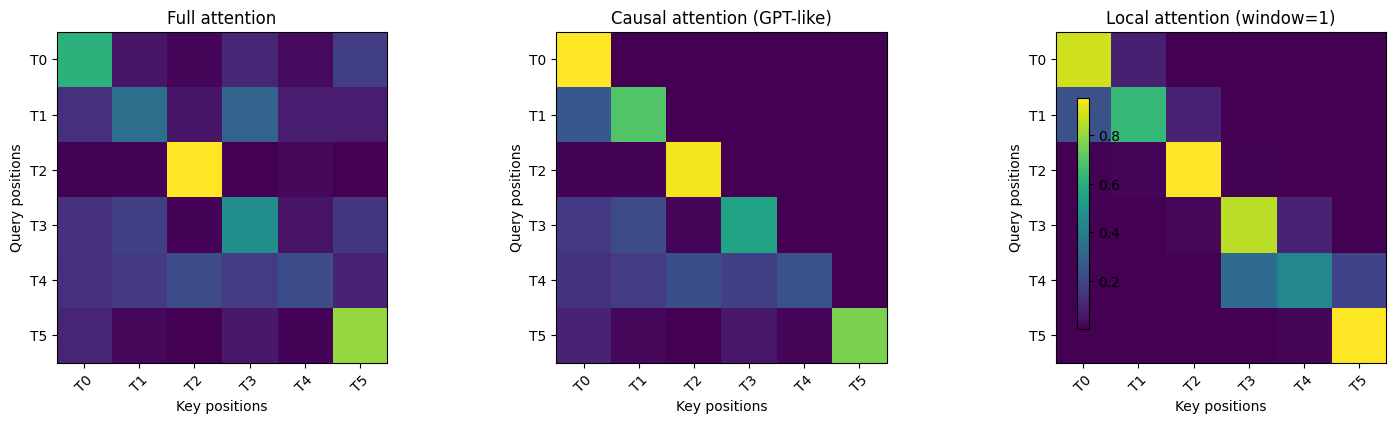

In [17]:
# Визуализируем full, causal и local attention
import matplotlib.pyplot as plt

def show_attention(ax, weights, title, tokens):
    im = ax.imshow(weights.detach().cpu().numpy(), cmap='viridis')
    ax.set_title(title)
    ax.set_xlabel('Key positions')
    ax.set_ylabel('Query positions')
    ax.set_xticks(range(len(tokens)))
    ax.set_yticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=45)
    ax.set_yticklabels(tokens)
    return im

tokens = [f'T{i}' for i in range(w_full.size(-1))]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
im = show_attention(axes[0], w_full[0], 'Full attention', tokens)
show_attention(axes[1], w_causal[0], 'Causal attention (GPT-like)', tokens)
show_attention(axes[2], w_local[0], 'Local attention (window=1)', tokens)
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.75)
plt.tight_layout()
plt.show()

## 4. Стратегии decoding

Рассмотрим, как параметры decoder в transformer позволяют управлять генерацией. Такие методы называют стратегиями decoding. Подробное описание приведено в [руководстве Hugging Face](https://huggingface.co/blog/how-to-generate), материалы которого частично использованы ниже.


In [18]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

torch_device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained("gpt2")

# Используем EOS token как PAD token, чтобы избежать предупреждений
model_for_decode = AutoModelForCausalLM.from_pretrained("gpt2", pad_token_id=tokenizer.eos_token_id).to(torch_device)

# Кодируем контекст, от которого зависит генерация
model_inputs = tokenizer('I enjoy walking with my cute dog', return_tensors='pt').to(torch_device)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

### 4.1 Greedy search

Самый простой вариант: на каждом шаге выбирается наиболее вероятный token.


In [19]:
# Генерируем 40 новых tokens
greedy_output = model_for_decode.generate(**model_inputs, max_new_tokens=40)

print("Output:\n" + 100 * '-')
print(tokenizer.decode(greedy_output[0], skip_special_tokens=True))


Output:
----------------------------------------------------------------------------------------------------
I enjoy walking with my cute dog, but I'm not sure if I'll ever be able to walk with my dog. I'm not sure if I'll ever be able to walk with my dog.

I'm not sure


### 4.2 Beam search

Beam search одновременно поддерживает несколько гипотез и на каждом шаге оставляет N лучших кандидатов.


In [20]:
# Включаем beam search и early_stopping
beam_output = model_for_decode.generate(
    **model_inputs,
    max_new_tokens=40,
    num_beams=5,
    early_stopping=True
)

print("Output:\n" + 100 * '-')
print(tokenizer.decode(beam_output[0], skip_special_tokens=True))

Output:
----------------------------------------------------------------------------------------------------
I enjoy walking with my cute dog, but I'm not sure if I'll ever be able to walk with him again.

I'm not sure if I'll ever be able to walk with him again. I'm not sure


Важное свойство beam search: после генерации можно сравнить лучшие beams и выбрать результат, который лучше всего подходит для задачи.

В `transformers` параметр `num_return_sequences` задаёт число возвращаемых beams с наибольшим score. При этом должно выполняться условие `num_return_sequences <= num_beams`.


In [21]:
# Устанавливаем num_return_sequences > 1
beam_outputs = model_for_decode.generate(
    **model_inputs,
    max_new_tokens=40,
    num_beams=5,
    no_repeat_ngram_size=2,
    num_return_sequences=5,
    early_stopping=True
)

# Теперь получаем несколько выходных последовательностей
print("Output:\n" + 100 * '-')
for i, beam_output in enumerate(beam_outputs):
  print("{}: {}".format(i, tokenizer.decode(beam_output, skip_special_tokens=True)))


Output:
----------------------------------------------------------------------------------------------------
0: I enjoy walking with my cute dog, but I'm not sure if I'll ever be able to walk with him again.

I've been thinking about this for a while now, and I think it's time for me to
1: I enjoy walking with my cute dog, but I'm not sure if I'll ever be able to walk with her again.

I've been thinking about this for a while now, and I think it's time for me to
2: I enjoy walking with my cute dog, but I'm not sure if I'll ever be able to walk with him again.

I've been thinking about this for a while now, and I think it's a good idea to
3: I enjoy walking with my cute dog, but I'm not sure if I'll ever be able to walk with him again.

I've been thinking about this for a while now, and I think it's time to take a
4: I enjoy walking with my cute dog, but I'm not sure if I'll ever be able to walk with him again.

I've been thinking about this for a while now, and I think it's a good idea

### 4.3 Sampling: temperature и top-k

При top-k sampling остаются K наиболее вероятных следующих tokens, а probability mass перераспределяется только между ними. Эта схема применялась в GPT-2 и помогала получать более разнообразные тексты.


In [22]:
# Включаем sampling и отключаем top-k, установив top_k=0
sample_output = model_for_decode.generate(
    **model_inputs,
    max_new_tokens=40,
    do_sample=True,
    top_k=0,
    temperature=0.6
)

print("Output:\n" + 100 * '-')
print(tokenizer.decode(sample_output[0], skip_special_tokens=True))


Output:
----------------------------------------------------------------------------------------------------
I enjoy walking with my cute dog. I don't think I can live without him, but I love him. I'm glad I'm home and I'm not going to have to be around him anymore."

O'Malley


### 4.4 top-p (nucleus) sampling

Вместо фиксированного числа K метод top-p выбирает минимальный набор наиболее вероятных tokens, суммарная вероятность которых не меньше p. Затем probability mass перераспределяется внутри этого набора. Поэтому число доступных tokens динамически меняется в зависимости от распределения вероятностей на текущем шаге.


In [23]:
sample_output = model_for_decode.generate(
    **model_inputs,
    max_new_tokens=40,
    do_sample=True,
    top_p=0.92,
    top_k=0
)

print("Output:\n" + 100 * '-')
print(tokenizer.decode(sample_output[0], skip_special_tokens=True))


Output:
----------------------------------------------------------------------------------------------------
I enjoy walking with my cute dog, the hoodie, the gloves, the blanket, the shoes, etc, etc. And one of the best things about working with Katie is how she works a bunch of custom made simple crochet design


Источники:

1. Статья о BERT (Devlin et al., 2018): https://arxiv.org/abs/1810.04805
2. Attention Is All You Need (Vaswani et al., 2017): https://arxiv.org/abs/1706.03762
3. Лекция Елены Войты о transfer learning: https://lena-voita.github.io/nlp_course/transfer_learning.html
4. Руководство Hugging Face по decoding: https://huggingface.co/blog/how-to-generate
5. Пример fine-tuning GPT-2 для классификации тональности: https://www.kaggle.com/code/evilmage93/gpt-2-finetuning-on-sentiment-classification
